# Notebook 03 — HCHO Hotspot Analysis
## ISRO Hackathon PS-03 — Objective 2: HCHO Hotspot Identification
This notebook documents the spatiotemporal HCHO analysis:
- Sentinel-5P TROPOMI HCHO column data over India (Oct–Nov 2024)
- Z-score anomaly detection (threshold σ > 1.5)
- DBSCAN spatial clustering for hotspot delineation
- Source region labelling


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from pathlib import Path
from scipy import stats

import os
os.chdir(r'C:\Users\91965\Desktop\vaadrish')

import nest_asyncio
nest_asyncio.apply()

plt.style.use('seaborn-v0_8-darkgrid')
fig_dir = Path('data/outputs/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

hcho_files = list(Path('data/raw/gee').glob('hcho_grid_*.csv'))
hcho_df = pd.read_csv(hcho_files[0])
print(f'Loaded {len(hcho_df)} HCHO grid points')
hcho_df.describe()


Loaded 4969 HCHO grid points


,lon,lat,hcho_value
count,4969.000000,4969.000000,4.969000e+03
mean,82.285530,20.794350,1.281302e-04
std,8.386530,8.740085,5.659891e-05
min,68.000100,6.067866,3.816114e-07
25%,75.052329,13.296474,8.761230e-05
50%,82.070227,20.579823,1.206790e-04
75%,89.535863,28.391532,1.688270e-04
max,96.989120,36.803428,3.686228e-04


## 1. HCHO Percentile Statistics


Mean HCHO : 1.2813e-04 mol/m²
Std Dev   : 5.6599e-05 mol/m²
95th %ile : 2.2707e-04 mol/m²
Max HCHO  : 3.6862e-04 mol/m²


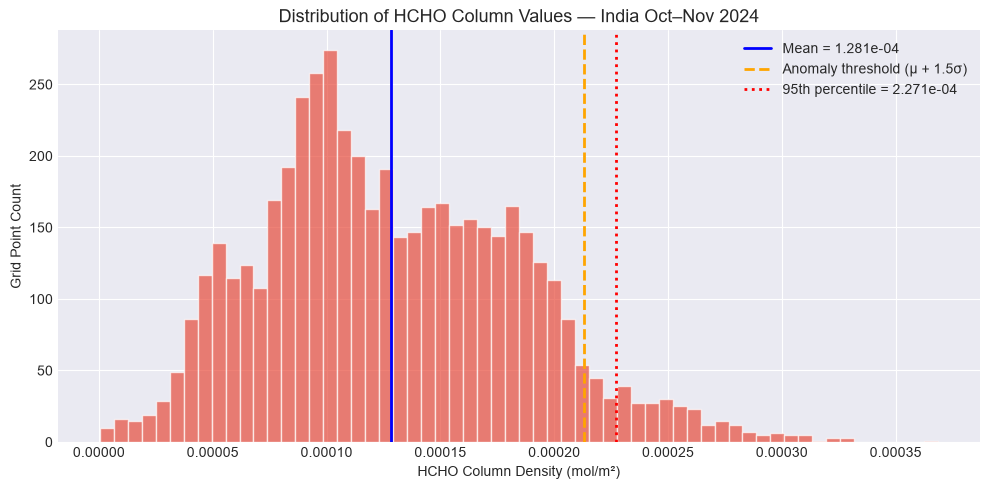

In [3]:
mean_hcho = hcho_df['hcho_value'].mean()
std_hcho  = hcho_df['hcho_value'].std()
p95       = hcho_df['hcho_value'].quantile(0.95)

print(f'Mean HCHO : {mean_hcho:.4e} mol/m²')
print(f'Std Dev   : {std_hcho:.4e} mol/m²')
print(f'95th %ile : {p95:.4e} mol/m²')
print(f'Max HCHO  : {hcho_df["hcho_value"].max():.4e} mol/m²')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(hcho_df['hcho_value'], bins=60, color='#e74c3c', alpha=0.7, edgecolor='white')
ax.axvline(mean_hcho, color='blue', linewidth=2, label=f'Mean = {mean_hcho:.3e}')
ax.axvline(mean_hcho + 1.5*std_hcho, color='orange', linewidth=2, linestyle='--', label='Anomaly threshold (μ + 1.5σ)')
ax.axvline(p95, color='red', linewidth=2, linestyle=':', label=f'95th percentile = {p95:.3e}')
ax.set_xlabel('HCHO Column Density (mol/m²)')
ax.set_ylabel('Grid Point Count')
ax.set_title('Distribution of HCHO Column Values — India Oct–Nov 2024', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(fig_dir / '09_hcho_distribution.png', dpi=150)
plt.show()


## 2. HCHO Anomaly Detection (Z-Score Method)


In [4]:
from ml.hcho_hotspot.detector import HCHOHotspotDetector
import sys
sys.path.insert(0, '..')

detector  = HCHOHotspotDetector(z_threshold=1.5, dbscan_eps=1.0, dbscan_min_samples=3)
anomalies = detector.detect_anomalies(hcho_df)
anomalies_only, hotspots = detector.cluster_hotspots(anomalies)

print(f'Total grid points  : {len(hcho_df):,}')
print(f'Anomaly points     : {anomalies["is_anomaly"].sum():,} '
      f'({100 * anomalies["is_anomaly"].mean():.1f}%)')
if not hotspots.empty:
    print(f'Hotspot clusters   : {len(hotspots)}')
    print(f'Extreme hotspots   : {(hotspots["intensity"] == "extreme").sum()}')
    print('\nHotspot Summary:')
    print(hotspots[['center_lat', 'center_lon', 'mean_hcho', 'max_hcho', 'intensity', 'point_count']].to_string(index=False))


Total grid points  : 4,969
Anomaly points     : 340 (6.8%)
Hotspot clusters   : 5
Extreme hotspots   : 0

Hotspot Summary:
 center_lat  center_lon  mean_hcho  max_hcho intensity  point_count
  28.771269   78.289131   0.000251  0.000369  moderate          263
  19.935033   72.877103   0.000235  0.000328  moderate           47
  23.042478   77.831262   0.000224  0.000254  moderate           11
  25.344826   76.463612   0.000216  0.000217  moderate            3
  20.831114   78.772683   0.000224  0.000233  moderate            3


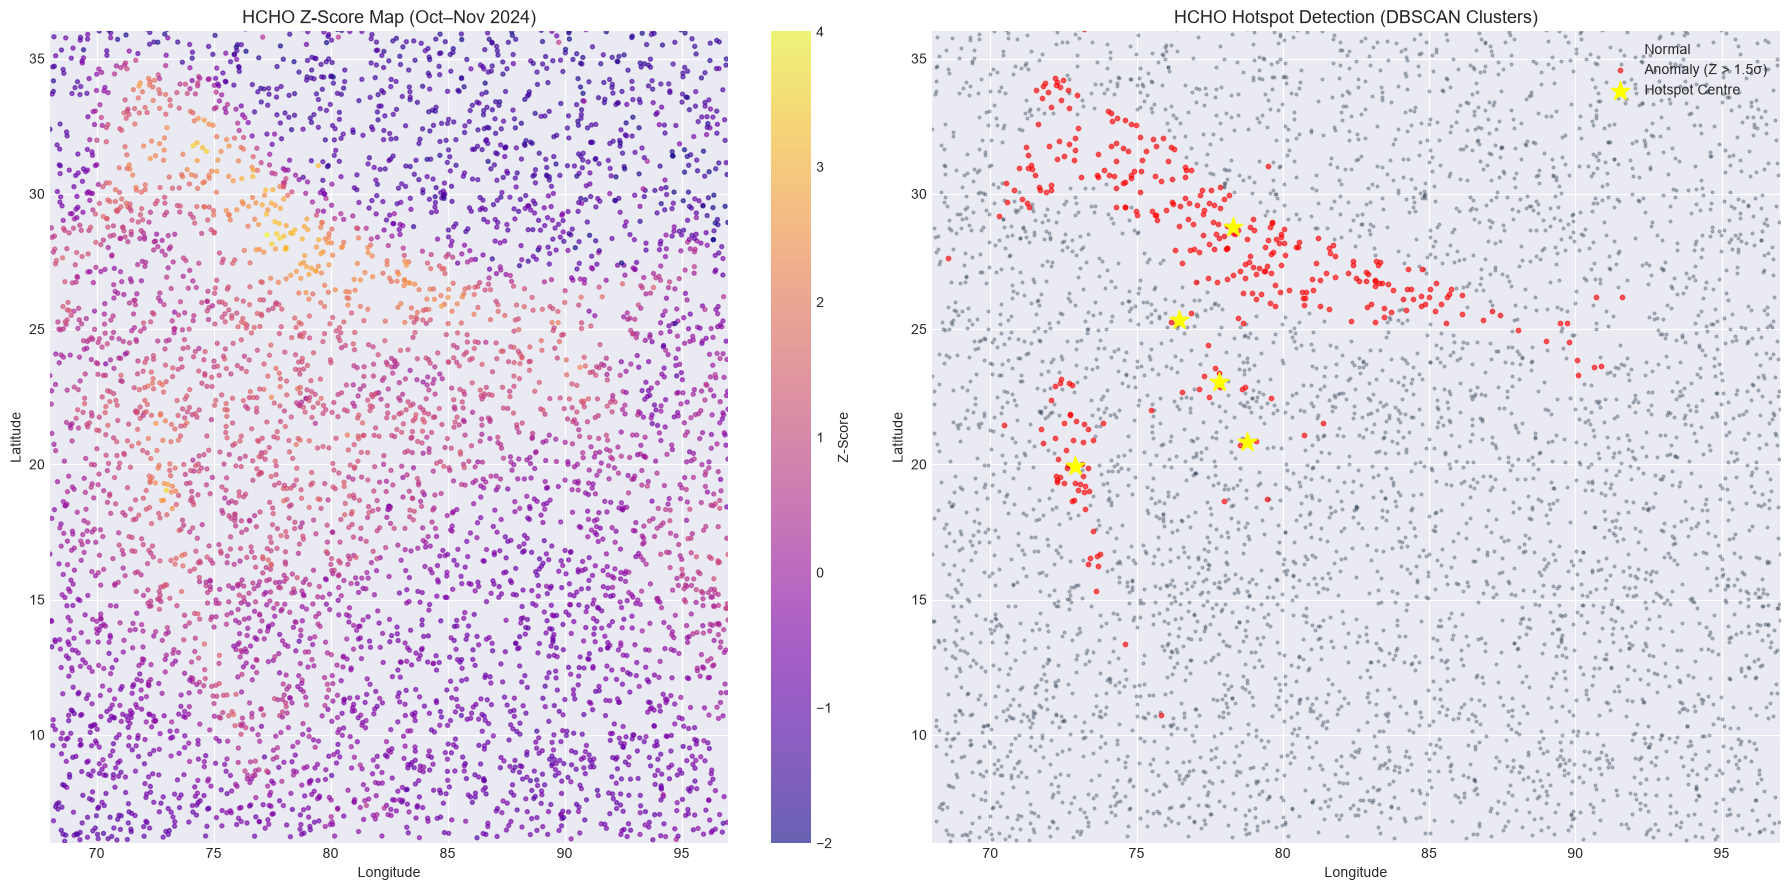

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Left: Z-score map
sc1 = axes[0].scatter(
    anomalies['lon'], anomalies['lat'],
    c=anomalies['z_score'], cmap='plasma',
    s=8, alpha=0.6, vmin=-2, vmax=4
)
plt.colorbar(sc1, ax=axes[0], label='Z-Score')
axes[0].set_title('HCHO Z-Score Map (Oct–Nov 2024)', fontsize=13)
axes[0].set_xlim(68, 97)
axes[0].set_ylim(6, 36)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Right: Hotspot overlay
normal    = anomalies[~anomalies['is_anomaly']]
anom_pts  = anomalies[anomalies['is_anomaly']]
axes[1].scatter(normal['lon'], normal['lat'], c='#2c3e50', s=4, alpha=0.3, label='Normal')
axes[1].scatter(anom_pts['lon'], anom_pts['lat'], c='red', s=10, alpha=0.6, label='Anomaly (Z > 1.5σ)')

if not hotspots.empty:
    axes[1].scatter(
        hotspots['center_lon'], hotspots['center_lat'],
        c='yellow', s=200, marker='*', zorder=5, label='Hotspot Centre'
    )

axes[1].set_title('HCHO Hotspot Detection (DBSCAN Clusters)', fontsize=13)
axes[1].set_xlim(68, 97)
axes[1].set_ylim(6, 36)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(fig_dir / '10_hcho_hotspots.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. HCHO by Source Region


             region  mean_hcho  max_hcho  n_hcho_points  total_frp  fire_count
      Central India   0.000183  0.000254            313    58403.6       16205
    Northwest India   0.000169  0.000272            103     6936.1        1390
Indo-Gangetic Plain   0.000167  0.000369            554   124518.3       26017
     Deccan Plateau   0.000164  0.000227            329    24449.6        6086
    Coastal Western   0.000141  0.000328            558     5081.2        1279
              Other   0.000108  0.000280           2866    27636.2       10417
    Northeast India   0.000107  0.000245            246     2069.4         699


C:\Users\91965\AppData\Local\Temp\ipykernel_91588\78865362.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(region_df['region'], rotation=20, ha='right')
C:\Users\91965\AppData\Local\Temp\ipykernel_91588\78865362.py:15: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\91965\AppData\Local\Temp\ipykernel_91588\78865362.py:16: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(fig_dir / '11_hcho_by_region.png', dpi=150)
C:\Users\91965\Desktop\vaadrish\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


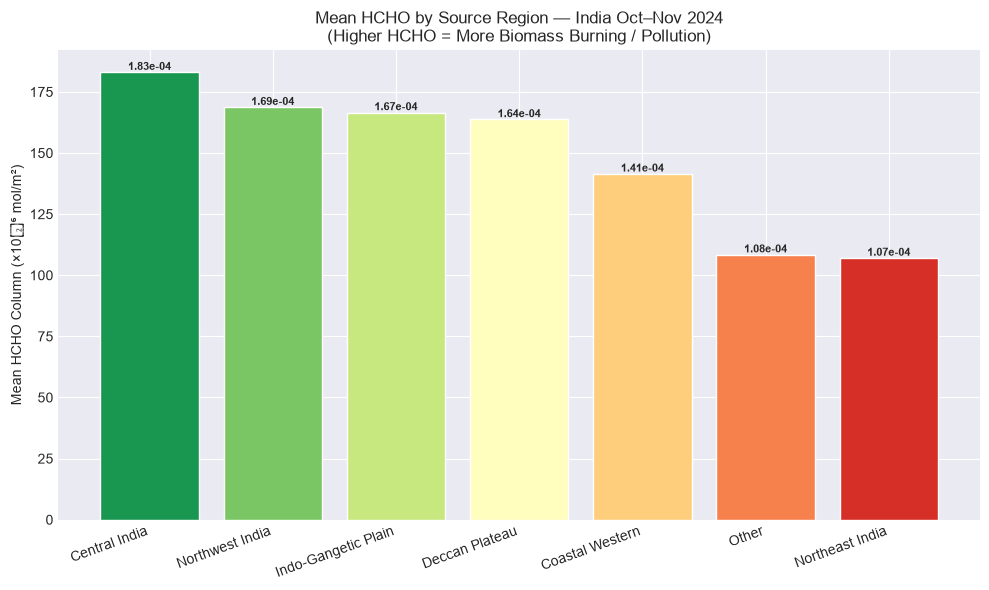

In [6]:
region_summary_path = Path('data/outputs/fire_hcho_region_summary.csv')
if region_summary_path.exists():
    region_df = pd.read_csv(region_summary_path)
    print(region_df.to_string(index=False))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(region_df)))
    bars = ax.bar(region_df['region'], region_df['mean_hcho'] * 1e6, color=colors, edgecolor='white')
    ax.set_ylabel('Mean HCHO Column (×10⁻⁶ mol/m²)')
    ax.set_title('Mean HCHO by Source Region — India Oct–Nov 2024\n(Higher HCHO = More Biomass Burning / Pollution)', fontsize=12)
    ax.set_xticklabels(region_df['region'], rotation=20, ha='right')
    for bar, val in zip(bars, region_df['mean_hcho']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.2e}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fig_dir / '11_hcho_by_region.png', dpi=150)
    plt.show()
else:
    print('Run the fire-HCHO analyzer first.')
